# 02 - Preprocesamiento

Escala de grises, filtro Gaussiano, redimensionamiento, normalizacion y vectorizacion.

In [1]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import preprocess_image
from src.config import IMAGE_SIZE

In [2]:
sample_images = list((PROJECT_ROOT / 'datasets').rglob('*.jpg')) + list((PROJECT_ROOT / 'datasets').rglob('*.png'))
sample_images[:5]

[PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/datasets/test/no_yawn/Aaron_Peirsol_0001.jpg'),
 PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/datasets/test/no_yawn/Aaron_Peirsol_0002.jpg'),
 PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/datasets/test/no_yawn/AndP_00537_m_21_i_fr_nc_hp_2015_1_e0_nl_o.jpg'),
 PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/datasets/test/no_yawn/Bill_Frist_0003.jpg'),
 PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/datasets/test/no_yawn/Blythe_Danner_0002.jpg')]

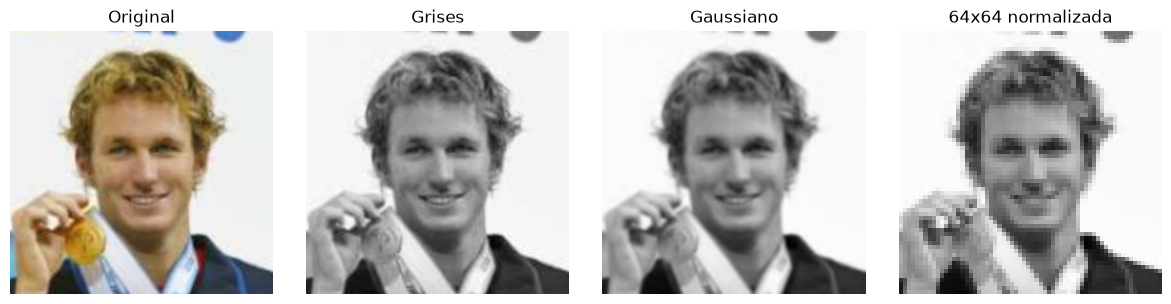

Vector: (4096,) Min: 0.07058824 Max: 0.9607843


In [3]:
if sample_images:
    image_path = sample_images[0]
    original = cv2.imread(str(image_path))
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    resized = cv2.resize(blurred, IMAGE_SIZE)
    normalized = resized.astype('float32') / 255.0
    vector = normalized.flatten()

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original')
    axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Grises')
    axes[2].imshow(blurred, cmap='gray'); axes[2].set_title('Gaussiano')
    axes[3].imshow(normalized, cmap='gray'); axes[3].set_title('64x64 normalizada')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()
    print('Vector:', vector.shape, 'Min:', vector.min(), 'Max:', vector.max())
else:
    print('Aun no hay imagenes en datasets/.')